In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.pairplot(df.drop(['Id'], axis = 1),
             hue='Species', height=2)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.heatmap(df.corr(method='pearson').drop(
  ['Id'], axis=1).drop(['Id'], axis=0),
            annot = True);
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from imblearn.under_sampling import RandomUnderSampler
from scipy.sparse import hstack

from sklearn.svm import SVC
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/colab/Fake_Dataset.csv')

Mounted at /content/drive


In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [ ]:
df.shape

(72134, 4)

In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


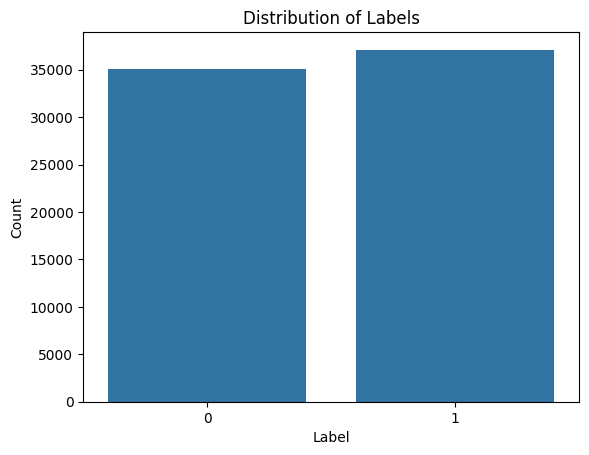

In [ ]:
sns.countplot(x='label', data=df)
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Distribution of Labels')
plt.show()

In [ ]:
df.dropna(how='any', inplace = True)
df.shape

(71537, 4)

In [ ]:
def clean_text(text):

  #substituting emailaddress
  text = re.sub(r'\S+@\S+','emailaddress',text)

  #substituting urls
  text = re.sub(r'https?://\S+|www\.\S+','url',text)

  #substituting numbers
  text = re.sub(r'\d+','number',text)

  #removing all punctuation marks
  text = text.translate(str.maketrans('','',string.punctuation))

  #text to lower case
  text = text.lower()

  return text

In [ ]:
df['title'] = df['title'].apply(clean_text)
df

,Unnamed: 0,title,text,label
0,0,law enforcement on high alert following threat...,No comment is expected from Barack Obama Membe...,1
2,2,unbelievable obama’s attorney general says mos...,"Now, most of the demonstrators gathered last ...",1
3,3,bobby jindal raised hindu uses story of christ...,A dozen politically active pastors came here f...,0
4,4,satan number russia unvelis an image of its te...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,about time christian group sues amazon and spl...,All we can say on this one is it s about time ...,1
...,...,...,...,...
72129,72129,russians steal research on trump in hack of us...,WASHINGTON (Reuters) - Hackers believed to be ...,0
72130,72130,watch giuliani demands that democrats apologi...,"You know, because in fantasyland Republicans n...",1
72131,72131,migrants refuse to leave train at refugee camp...,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,trump tussle gives unpopular mexican leader mu...,MEXICO CITY (Reuters) - Donald Trump’s combati...,0


In [ ]:
def tokenize_stopWord(text):

  stop_words = set(stopwords.words('english'))
  words = word_tokenize(text)
  filtered_words = [word for word in words if word not in stop_words]

  lemmatizer = WordNetLemmatizer()
  lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_words]


  return ' '.join(lemmatized_tokens)

In [ ]:
df['title'] = df['title'].apply(tokenize_stopWord)

In [ ]:
df['text'] = df['text'].apply(tokenize_stopWord)

In [ ]:
df

,Unnamed: 0,title,text,label
0,0,law enforcement high alert following threat co...,No comment expected Barack Obama Members # FYF...,1
2,2,unbelievable obama ’ attorney general say char...,"Now , demonstrator gathered last night exercis...",1
3,3,bobby jindal raised hindu us story christian c...,A dozen politically active pastor came private...,0
4,4,satan number russia unvelis image terrifying n...,"The RS-28 Sarmat missile , dubbed Satan 2 , re...",1
5,5,time christian group sue amazon splc designati...,All say one time someone sued Southern Poverty...,1
...,...,...,...,...
72129,72129,russian steal research trump hack u democratic...,WASHINGTON ( Reuters ) - Hackers believed work...,0
72130,72130,watch giuliani demand democrat apologize trump...,"You know , fantasyland Republicans never quest...",1
72131,72131,migrant refuse leave train refugee camp hungary,Migrants Refuse To Leave Train At Refugee Camp...,0
72132,72132,trump tussle give unpopular mexican leader muc...,MEXICO CITY ( Reuters ) - Donald Trump ’ comba...,0


In [ ]:
# ✅ Step 1: Combine title and text into one column
df['combined_text'] = df['title'] + " " + df['text']

# ✅ Step 2: Use a single TfidfVectorizer on combined text
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=15000)  # Increased features to capture more info
X_combined_tfidf = vectorizer.fit_transform(df['combined_text'])

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

# ✅ Handle class imbalance using RandomUnderSampler
y = df['label']  # Assuming the target column is 'label'
resampler = RandomUnderSampler(random_state=0)
X_resampled, y_resampled = resampler.fit_resample(X_combined_tfidf, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(C=1.5, max_iter=1000),
    'RandomForest': RandomForestClassifier(n_estimators=500, max_depth=20),
    'SVM': SVC(C=1.5, probability=True),
    'XGBoost': XGBClassifier(n_estimators=500, max_depth=20)
    }

In [ ]:
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    cr = classification_report(y_test, y_pred)

    # Store the trained model in results
    results[model_name] = {
        "accuracy": accuracy,
        "confusion_matrix": cm,
        "classification_report": cr,
        "model": model  # Added this line to store the model
    }

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy}")
    print(f"Classification Report:\n{cr}")


Model: LogisticRegression
Accuracy: 0.9563686539468049
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     10476
           1       0.95      0.96      0.96     10541

    accuracy                           0.96     21017
   macro avg       0.96      0.96      0.96     21017
weighted avg       0.96      0.96      0.96     21017

Model: RandomForest
Accuracy: 0.9351477375457963
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     10476
           1       0.92      0.95      0.94     10541

    accuracy                           0.94     21017
   macro avg       0.94      0.94      0.94     21017
weighted avg       0.94      0.94      0.94     21017



In [ ]:
# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title(f"Confusion Matrix for {model_name}")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
# Step 7: Compare models based on accuracy
best_model = max(results, key=lambda x: results[x]['accuracy'])
print(f"Best Model: {best_model} with accuracy: {results[best_model]['accuracy']}")

In [ ]:
import joblib

# ✅ Step 8: Find the best model based on accuracy
best_model = max(results, key=lambda x: results[x]['accuracy'])
best_model_object = results[best_model]['model']

# ✅ Save the best model
joblib.dump(best_model_object, 'best_model.pkl')

# ✅ Save the combined trained vectorizer (used during training)
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

print(f"✅ Best model saved as 'best_model.pkl'")
print(f"✅ Vectorizer saved as 'tfidf_vectorizer.pkl'")

In [ ]:
from google.colab import files

# Download best model and vectorizer
files.download('best_model.pkl')
files.download('tfidf_vectorizer.pkl')
